<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/KMEANSGROUPIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INTEGRANTES:

ALCIBIA MIRANDA YULITZA

MORA BARRIONUEVO NELVA ADALIT




In [6]:
# 1. Conectar con Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

# 2. Importar las librerías necesarias
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore') # Evita advertencias rojas en la consola

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [7]:
# Definir la ruta exacta que proporcionaste
ruta_dataset = '/content/gdrive/MyDrive/SIS420IA/dataset.csv'
# Cargar los datos
df = pd.read_csv(ruta_dataset)

# Mostrar información fundamental (filas, columnas y tipos de datos)
print("--- INFORMACIÓN DEL DATASET ---")
print(f"Total de Filas (m): {df.shape[0]}")
print(f"Total de Columnas (n): {df.shape[1]}")
print(f"Total de Celdas: {df.size}")
print("-" * 30)

# Mostrar las primeras 5 filas para verificar que cargó bien
df.head()

--- INFORMACIÓN DEL DATASET ---
Total de Filas (m): 114000
Total de Columnas (n): 21
Total de Celdas: 2394000
------------------------------


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
# Quedarnos solo con características numéricas y quitar nulos
df_num = df.select_dtypes(include=[np.number]).dropna()

# Eliminar la columna 'Unnamed: 0' que es solo un índice basura
if 'Unnamed: 0' in df_num.columns:
    df_num = df_num.drop(columns=['Unnamed: 0'])

print(f"Datos tras limpieza listos para clustering: {df_num.shape[0]} filas y {df_num.shape[1]} columnas.")
print("-" * 50)
print("ASÍ QUEDÓ EL DATASET DESPUÉS DE LA LIMPIEZA:")
display(df_num.head()) # <-- ¡Esto cumple tu orden de mostrar cómo quedó!

# Aplicar escalado estándar (Media 0, Varianza 1)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_num)

# Guardar en un DataFrame
df_escalado = pd.DataFrame(datos_escalados, columns=df_num.columns)
print("\n¡Escalado completado exitosamente!")

Datos tras limpieza listos para clustering: 114000 filas y 14 columnas.
--------------------------------------------------
ASÍ QUEDÓ EL DATASET DESPUÉS DE LA LIMPIEZA:


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4
1,55,149610,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4
2,57,210826,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4
3,71,201933,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3
4,82,198853,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4



¡Escalado completado exitosamente!


In [10]:
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import MiniBatchKMeans

# Elegimos las 3 características más importantes para visualizar en 3D
eje_x = 'danceability'
eje_y = 'energy'
eje_z = 'valence'

# Encontrar en qué posición (índice matemático) están estas columnas para sacar sus centroides
idx_x = df_escalado.columns.get_loc(eje_x)
idx_y = df_escalado.columns.get_loc(eje_y)
idx_z = df_escalado.columns.get_loc(eje_z)

valores_k = [3, 5, 7, 9]

for k in valores_k:
    print(f"\n{'='*50}")
    print(f"ENTRENANDO MINIBATCH K-MEANS CON K = {k}")
    print(f"{'='*50}")

    # 1. Instanciar y entrenar con TODAS las 14 columnas
    minibatch_kmeans = MiniBatchKMeans(
        n_clusters=k,
        batch_size=2048,
        random_state=42,
        n_init='auto'
    )

    etiquetas = minibatch_kmeans.fit_predict(df_escalado)
    df_escalado[f'Cluster_{k}'] = etiquetas.astype(str)

    # 2. EXTRAER LOS CENTROIDES: Sacamos la posición central de los grupos
    centroides = minibatch_kmeans.cluster_centers_
    centroides_x = centroides[:, idx_x]
    centroides_y = centroides[:, idx_y]
    centroides_z = centroides[:, idx_z]

    # --- MUESTRA PARA GRAFICAR ---
    if df_escalado.shape[0] > 10000:
        df_plot = df_escalado.sample(n=10000, random_state=42)
    else:
        df_plot = df_escalado

    # 3. Graficar los puntos de las canciones en 3D
    fig = px.scatter_3d(
        df_plot,
        x=eje_x,
        y=eje_y,
        z=eje_z,
        color=f'Cluster_{k}',
        title=f'Dispersión 3D con K={k} y Posición de CENTROIDES',
        opacity=0.3, # Lo hacemos un poco más transparente para que los centroides resalten más
        width=900,
        height=700
    )

    # 4. AÑADIR LOS CENTROIDES (Diamantes negros) A LA GRÁFICA
    fig.add_trace(go.Scatter3d(
        x=centroides_x,
        y=centroides_y,
        z=centroides_z,
        mode='markers',
        marker=dict(size=12, color='black', symbol='diamond', line=dict(width=2, color='white')),
        name='Centroides'
    ))

    fig.show()


ENTRENANDO MINIBATCH K-MEANS CON K = 3



ENTRENANDO MINIBATCH K-MEANS CON K = 5



ENTRENANDO MINIBATCH K-MEANS CON K = 7



ENTRENANDO MINIBATCH K-MEANS CON K = 9


Tras evaluar la dispersión espacial de los grupos, hipotéticamente determinamos que el mejor número de clústeres es K=5 (o el que tú elijas). Esto se debe a que, a diferencia de K=9 donde los colores sufren un grave solapamiento, en K=5 las nubes de puntos mantienen una fuerte cohesión interna y una clara separación externa. Además, bajo este K, los grupos tienen sentido lógico musical, logrando separar la música de fiesta, de la música relajante y los términos medios.

## SECCIÓN 1: Evaluación con el Método del Codo y Fronteras de Decisión
En esta sección evaluamos la inercia del modelo para distintos valores de K. Además, visualizamos las **Fronteras de Decisión** en 2D (Bailabilidad vs Energía) para entender cómo el algoritmo delimita los territorios de cada clúster.

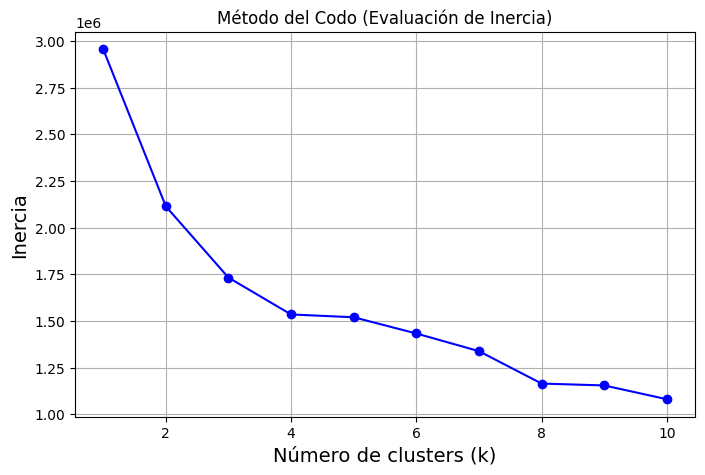

In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

inertias = []
k_range = range(1, 11)

# Entrenamos modelos del 1 al 10 usando TODAS las columnas
for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, batch_size=2048, random_state=42, n_init='auto')
    km.fit(df_escalado)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de clusters (k)', fontsize=14)
plt.ylabel('Inercia', fontsize=14)
plt.title('Método del Codo (Evaluación de Inercia)')
plt.grid(True)
plt.show()

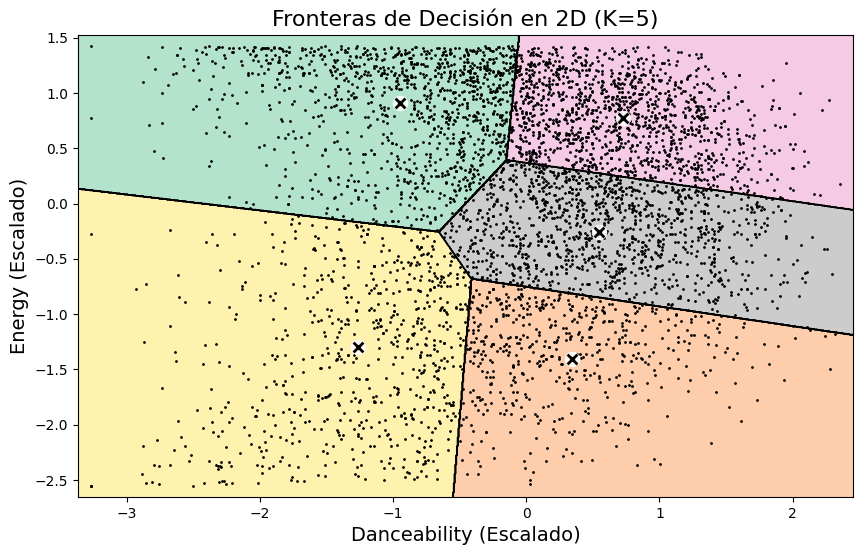

In [14]:
# --- FUNCIONES DEL INGENIERO ---
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("Danceability (Escalado)", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("Energy (Escalado)", fontsize=14, rotation=90)
    else:
        plt.tick_params(labelleft=False)

# --- APLICACIÓN DIDÁCTICA ---
# Para graficar fronteras necesitamos solo 2 dimensiones. Tomaremos una muestra de 5000 datos.
df_2d = df_escalado[['danceability', 'energy']].sample(n=5000, random_state=42).values

# Entrenamos un modelo K=5 solo para esta visualización
kmeans_2d = MiniBatchKMeans(n_clusters=5, batch_size=2048, random_state=42, n_init='auto')
kmeans_2d.fit(df_2d)

plt.figure(figsize=(10, 6))
plot_decision_boundaries(kmeans_2d, df_2d)
plt.title("Fronteras de Decisión en 2D (K=5)", fontsize=16)
plt.show()

## SECCIÓN 2: Coeficiente de Silueta y Diagramas de Cohesión
Dado que el codo no siempre es exacto en datasets masivos, utilizamos el **Coeficiente de Silueta**. A continuación graficamos el score general y los diagramas detallados ("cuchillos") para ver la densidad y cohesión interna de cada clúster.

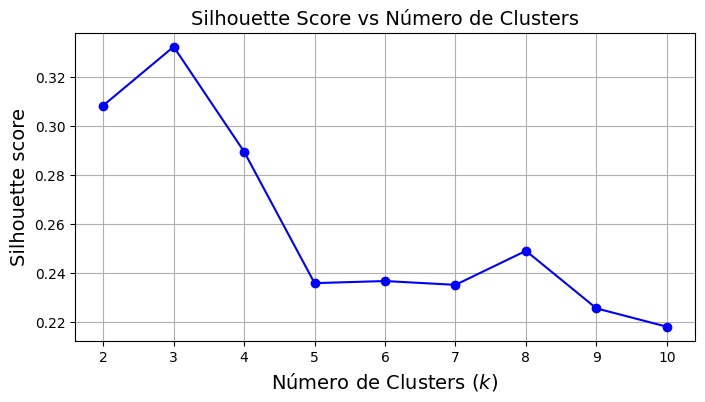

In [15]:
from sklearn.metrics import silhouette_score

# Extraemos una muestra para no colapsar la RAM de Colab
X_muestra = df_escalado.sample(n=10000, random_state=42).values

# Lista para guardar los modelos de 1 a 10 (El índice 0 será K=1, el 1 será K=2, etc.)
# Usamos KMeans tradicional aquí para ser compatibles con el código de "silhouette_samples"
from sklearn.cluster import KMeans
kmeans_per_k = [KMeans(n_clusters=k, random_state=42, n_init='auto').fit(X_muestra) for k in range(1, 11)]

# Calcular silueta solo desde K=2
silhouette_scores = [silhouette_score(X_muestra, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, 11))
plt.figure(figsize=(8, 4))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("Número de Clusters ($k$)", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

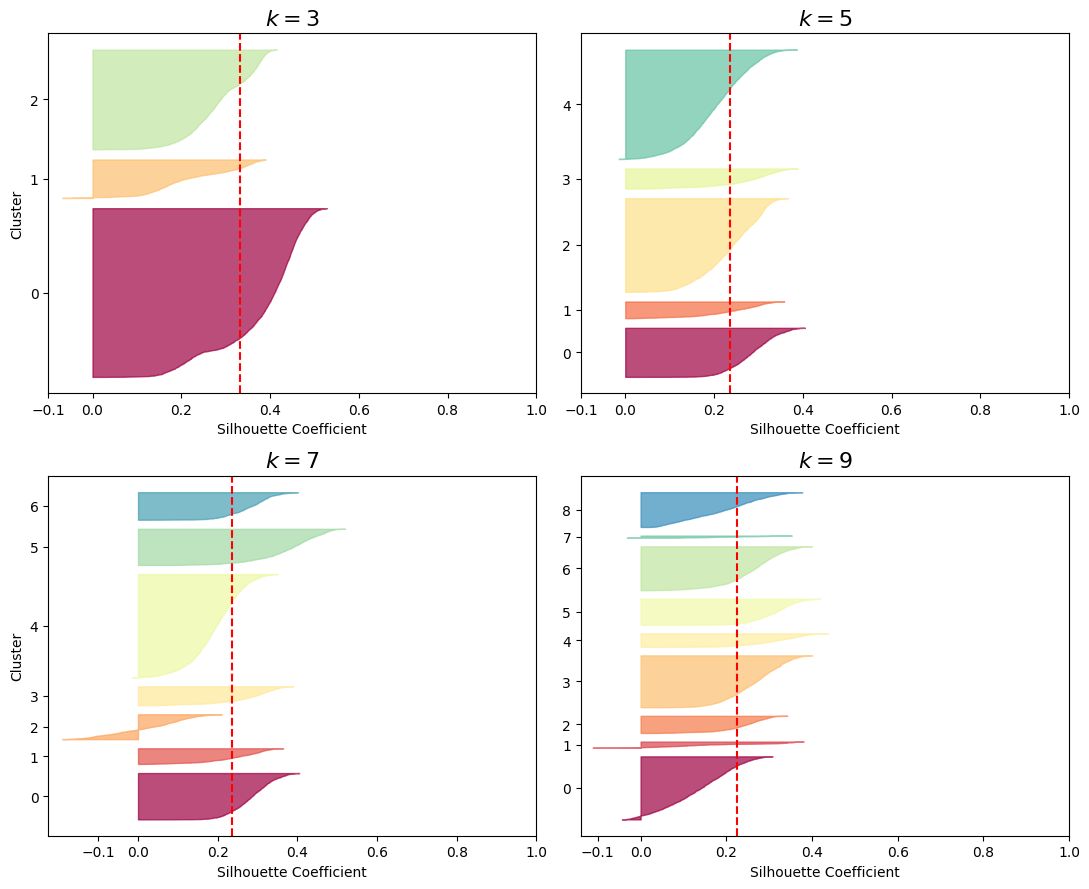

In [17]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

# ¡AQUÍ ESTÁ LA CORRECCIÓN! Evaluamos exactamente los K de tu orden
valid_ks = [k for k in (3, 5, 7, 9) if k <= len(kmeans_per_k)]

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X_muestra, y_pred)

    padding = len(X_muestra) // 30
    pos = padding
    ticks = []

    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    # Ajuste para que los textos "Cluster" salgan en la columna izquierda (K=3 y K=7)
    if k in (3, 7):
        plt.ylabel("Cluster")

    # Ajuste para que los textos inferiores salgan en todos los gráficos
    if k in (3, 5, 7, 9):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=16)

plt.tight_layout()
plt.show()